# Xeno-canto Gathering

Build a reproducible download set using XC query tags.


In [1]:
import json
import sys
import time
from pathlib import Path

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "config.py").exists():
    repo_root = repo_root.parent
if not (repo_root / "src" / "config.py").exists():
    raise FileNotFoundError(f"Couldn't find src/config.py from {Path.cwd()}")

sys.path.insert(0, str(repo_root))

from src.config import CONFIG
from src.dataset.utils.xeno_canto import (
    download_from_selected_manifest,
    manifest_path,
    write_raw_manifest_for_species,
)
from src.dataset.utils.gathering import read_manifest_csv, write_selected_manifests


In [2]:
DATA_DIR = Path(CONFIG.paths.data_dir)
RAW_DIR = DATA_DIR / CONFIG.paths.raw_dir
MANIFEST_DIR = DATA_DIR / CONFIG.paths.manifests_dir

for p in [RAW_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)
    
SPECIES_FILE = Path("../../species_list_small.json")
species_map = json.loads(SPECIES_FILE.read_text(encoding="utf-8"))
species_list = list(species_map.values())
species_list[:5]

[{'common_name': 'European Robin', 'sci_name': 'Erithacus rubecula'},
 {'common_name': 'Eurasian Blackbird', 'sci_name': 'Turdus merula'},
 {'common_name': 'Eurasian Wren', 'sci_name': 'Troglodytes troglodytes'},
 {'common_name': 'Eurasian Blue Tit', 'sci_name': 'Cyanistes caeruleus'},
 {'common_name': 'Great Tit', 'sci_name': 'Parus major'}]

In [3]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent  # or walk parents robustly

DATA_DIR = PROJECT_ROOT / CONFIG.paths.data_dir
RAW_DIR = DATA_DIR / CONFIG.paths.raw_dir
MANIFEST_DIR = DATA_DIR / CONFIG.paths.manifests_dir
print(MANIFEST_DIR, len(list(MANIFEST_DIR.glob("*_selected.csv"))))


/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests 0


In [4]:
def build_query(sci_name: str) -> str:
    xc = CONFIG.xeno_canto
    tags = [
        f'sp:"{sci_name}"',
        "grp:birds",
        "area:europe",
        'q:">E"',                 
        f'len:">{xc.min_len}"',
        f'len:"<{xc.max_len}"',
    ]
    return " ".join(tags)


## Fetch metadata and store in manifest files


In [5]:
for entry in species_list:
    sci_name = entry["sci_name"]
    query = build_query(sci_name)

    out_csv = write_raw_manifest_for_species(
        sci_name=sci_name,
        query=query,
        manifest_dir=MANIFEST_DIR,
        per_page=500,
    )

    print(f"Wrote raw manifest: {out_csv}")


Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/erithacus_rubecula.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/turdus_merula.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/troglodytes_troglodytes.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/cyanistes_caeruleus.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/parus_major.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/carduelis_carduelis.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/fringilla_coelebs.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/turdus_philomelos.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/pica_pica.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests

In [6]:
selected_manifest_paths = write_selected_manifests(
    MANIFEST_DIR,
    target_per_species=350,
    recordist_cap=30,
    prefer_countries=("Ireland", "United Kingdom"),
    prefer_qualities=tuple(CONFIG.xeno_canto.quality),
    selected_suffix="selected",
)

print("Wrote selected manifests:", len(selected_manifest_paths))
for p in selected_manifest_paths:
    print(" -", p)


Wrote selected manifests: 50
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/accipiter_nisus_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/acrocephalus_schoenobaenus_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/aegithalos_caudatus_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/alcedo_atthis_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/anthus_pratensis_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/apus_apus_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/buteo_buteo_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/carduelis_carduelis_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/chloris_chloris_selected.csv
 - /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/manifests/cinclus_cinclus_selected.csv
 - /Users/justyna-przy/Projects/I

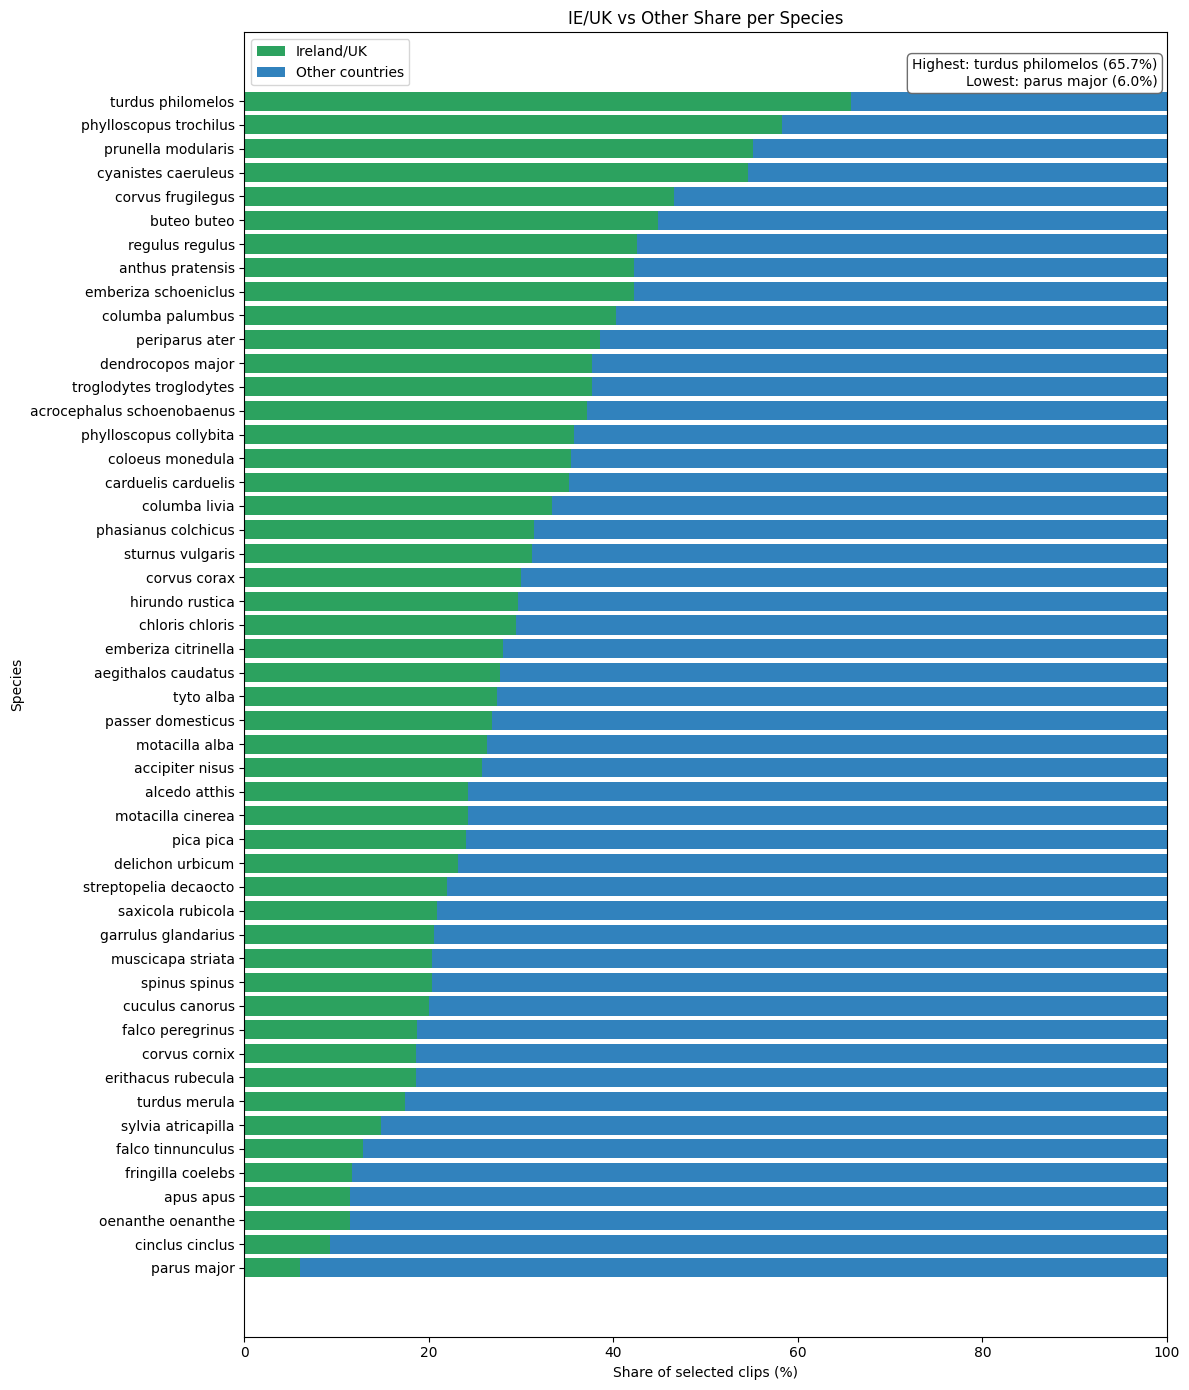

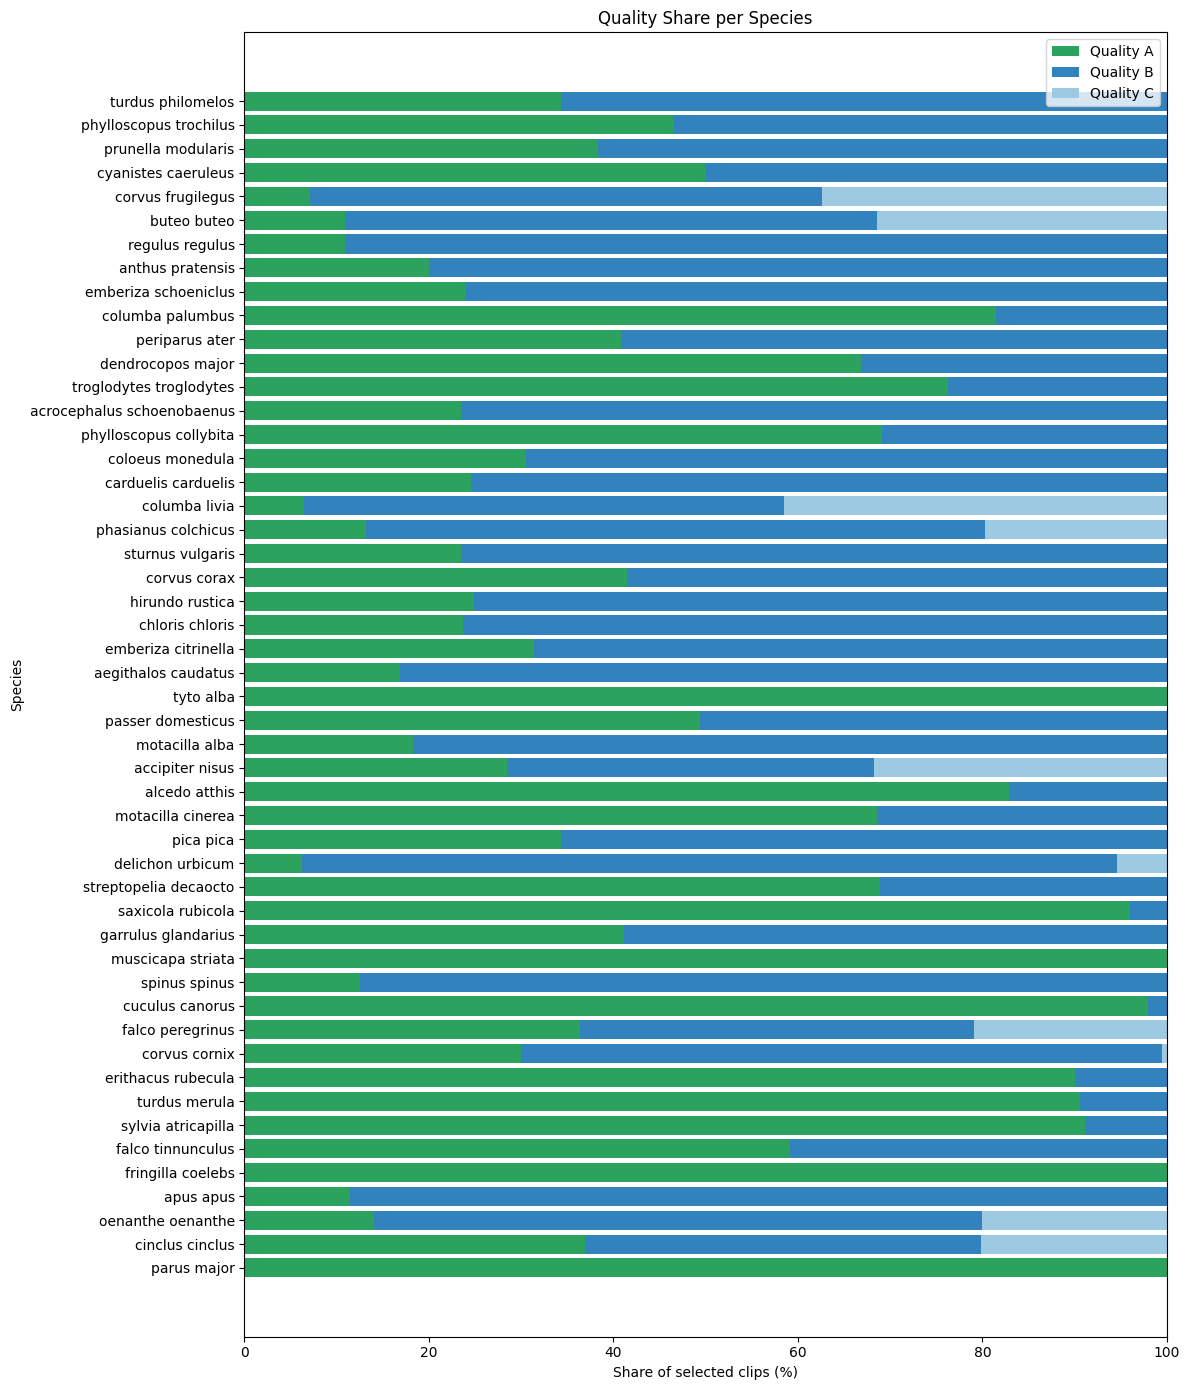

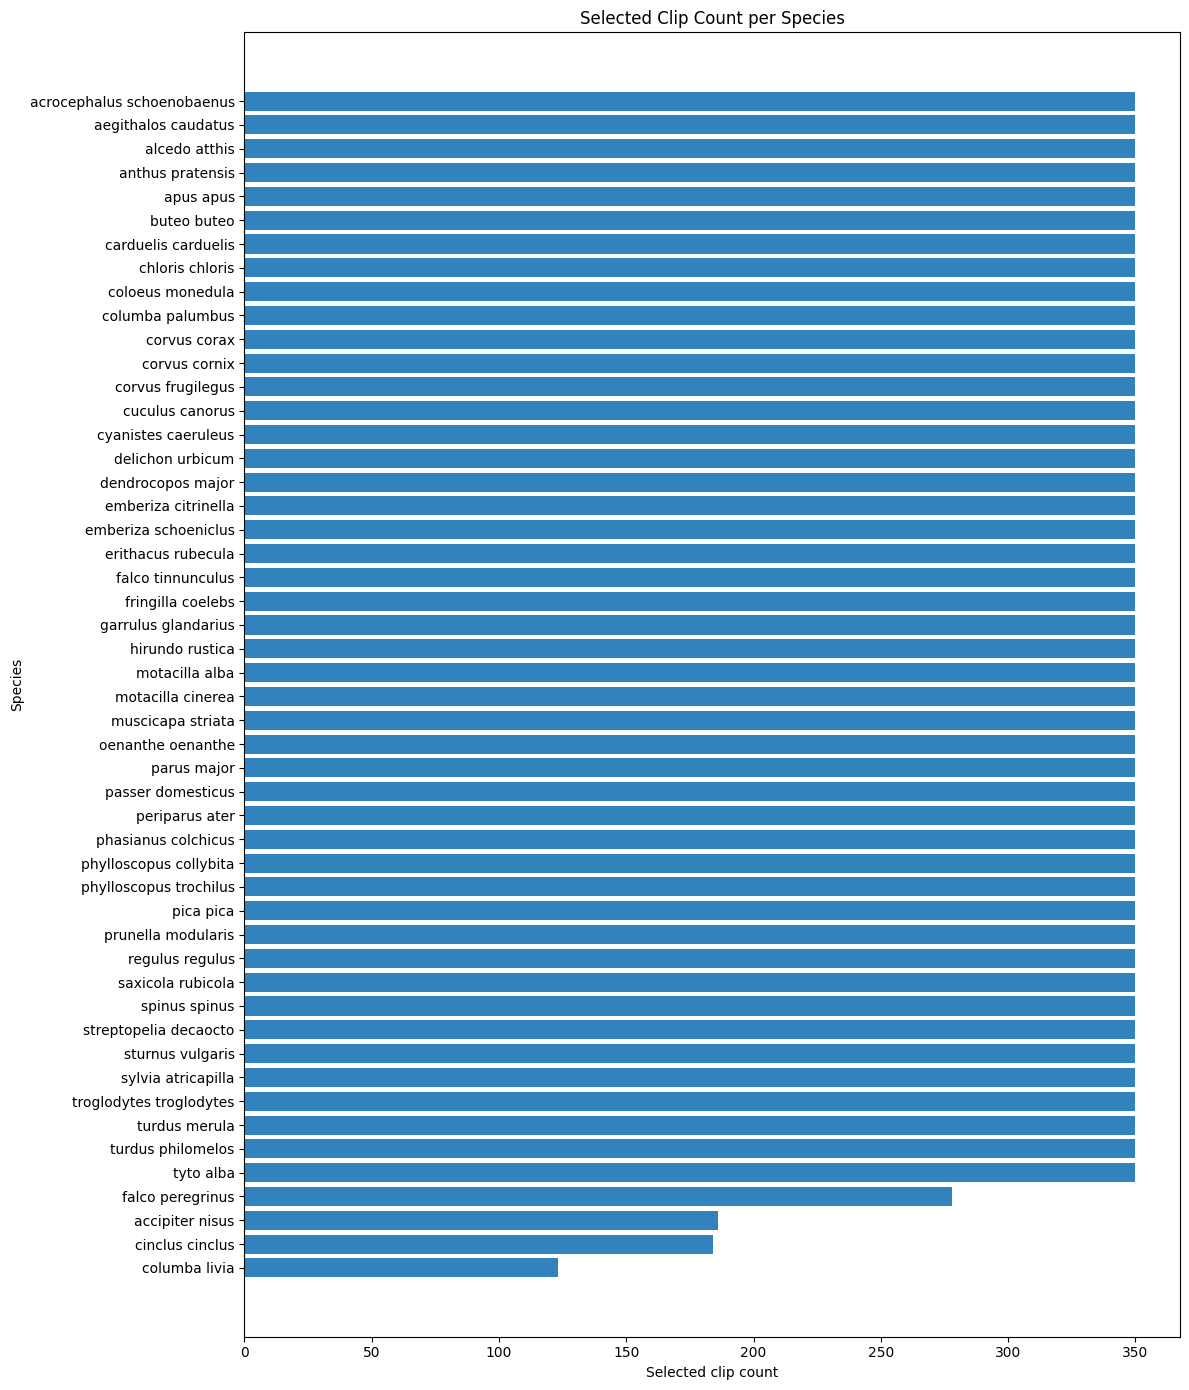

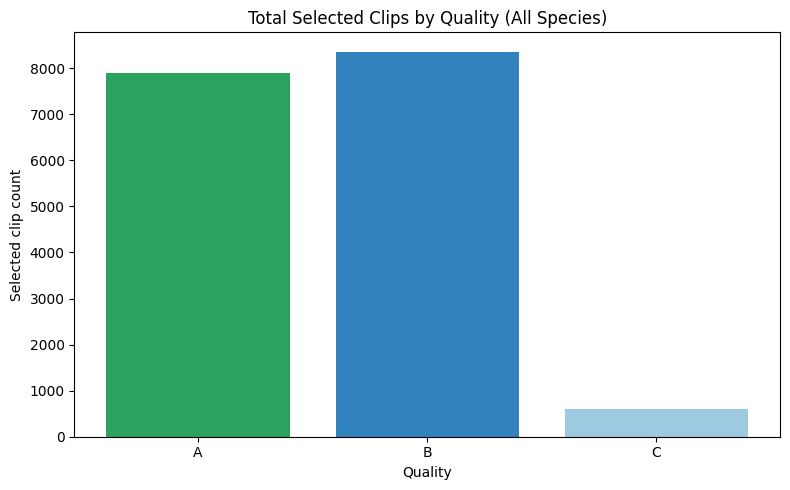

In [9]:
from collections import Counter

import matplotlib.pyplot as plt

valid_species_names = sorted({entry["sci_name"].strip() for entry in species_list if entry.get("sci_name")})
preferred_countries = {"Ireland", "United Kingdom"}
quality_levels = ["A", "B", "C"]

species_stats = []
quality_totals = Counter()

for sci_name in valid_species_names:
    selected_csv = manifest_path(MANIFEST_DIR, sci_name, "selected")
    if not selected_csv.exists():
        continue

    rows, _ = read_manifest_csv(selected_csv)
    if not rows:
        continue

    total_count = len(rows)
    ie_uk_count = 0
    quality_counts = Counter()

    for row in rows:
        country = (row.get("country") or "").strip()
        if country in preferred_countries:
            ie_uk_count += 1

        quality = (row.get("quality") or "").strip().upper()
        if quality in quality_levels:
            quality_counts[quality] += 1
            quality_totals[quality] += 1

    quality_denominator = sum(quality_counts[level] for level in quality_levels)
    if quality_denominator == 0:
        quality_denominator = total_count

    ie_uk_pct = (ie_uk_count / total_count * 100.0) if total_count else 0.0
    species_stats.append(
        {
            "species_sci": sci_name.lower(),
            "total_count": total_count,
            "ie_uk_pct": ie_uk_pct,
            "other_pct": max(0.0, 100.0 - ie_uk_pct),
            "a_pct": (quality_counts["A"] / quality_denominator * 100.0) if quality_denominator else 0.0,
            "b_pct": (quality_counts["B"] / quality_denominator * 100.0) if quality_denominator else 0.0,
            "c_pct": (quality_counts["C"] / quality_denominator * 100.0) if quality_denominator else 0.0,
        }
    )

if not species_stats:
    raise RuntimeError("No selected manifest rows found for the configured species list.")

species_stats_ieuk = sorted(species_stats, key=lambda item: item["ie_uk_pct"], reverse=True)
species_labels = [item["species_sci"] for item in species_stats_ieuk]
ie_uk_pcts = [item["ie_uk_pct"] for item in species_stats_ieuk]
other_pcts = [item["other_pct"] for item in species_stats_ieuk]

fig, ax = plt.subplots(figsize=(12, max(10, 0.28 * len(species_stats_ieuk))))
ax.barh(species_labels, ie_uk_pcts, color="#2ca25f", label="Ireland/UK")
ax.barh(species_labels, other_pcts, left=ie_uk_pcts, color="#3182bd", label="Other countries")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of selected clips (%)")
ax.set_ylabel("Species")
ax.set_title("IE/UK vs Other Share per Species")
ax.legend(loc="upper left")

highest = species_stats_ieuk[0]
lowest = species_stats_ieuk[-1]
callout = (
    f"Highest: {highest['species_sci']} ({highest['ie_uk_pct']:.1f}%)\n"
    f"Lowest: {lowest['species_sci']} ({lowest['ie_uk_pct']:.1f}%)"
)
ax.text(
    0.99,
    0.98,
    callout,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#666666", "alpha": 0.95},
)
plt.tight_layout()
plt.show()

a_pcts = [item["a_pct"] for item in species_stats_ieuk]
b_pcts = [item["b_pct"] for item in species_stats_ieuk]
c_pcts = [item["c_pct"] for item in species_stats_ieuk]
ab_pcts = [a + b for a, b in zip(a_pcts, b_pcts)]

fig, ax = plt.subplots(figsize=(12, max(10, 0.28 * len(species_stats_ieuk))))
ax.barh(species_labels, a_pcts, color="#2ca25f", label="Quality A")
ax.barh(species_labels, b_pcts, left=a_pcts, color="#3182bd", label="Quality B")
ax.barh(species_labels, c_pcts, left=ab_pcts, color="#9ecae1", label="Quality C")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of selected clips (%)")
ax.set_ylabel("Species")
ax.set_title("Quality Share per Species")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

species_stats_count = sorted(species_stats, key=lambda item: item["total_count"], reverse=True)
count_labels = [item["species_sci"] for item in species_stats_count]
selected_counts = [item["total_count"] for item in species_stats_count]

fig, ax = plt.subplots(figsize=(12, max(10, 0.28 * len(species_stats_count))))
ax.barh(count_labels, selected_counts, color="#3182bd")
ax.invert_yaxis()
ax.set_xlabel("Selected clip count")
ax.set_ylabel("Species")
ax.set_title("Selected Clip Count per Species")
plt.tight_layout()
plt.show()

overall_quality_counts = [quality_totals[level] for level in quality_levels]
overall_quality_labels = quality_levels
quality_colors = {
    "A": "#2ca25f",
    "B": "#3182bd",
    "C": "#9ecae1",
    "D": "#6baed6",
    "E": "#c6dbef",
}
bar_colors = [quality_colors.get(level, "#9e9e9e") for level in overall_quality_labels]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(overall_quality_labels, overall_quality_counts, color=bar_colors)
ax.set_xlabel("Quality")
ax.set_ylabel("Selected clip count")
ax.set_title("Total Selected Clips by Quality (All Species)")
plt.tight_layout()
plt.show()


In [ ]:
SKIP_SCI = set()

species_to_download = sorted({entry["sci_name"].strip() for entry in species_list if entry.get("sci_name")})
print("Species in list:", len(species_to_download))


downloaded = []
for sci in species_to_download:
    if sci in SKIP_SCI:
        print(f"Skipping {sci} (in SKIP_SCI)")
        continue

    selected_csv = manifest_path(MANIFEST_DIR, sci, "selected")
    downloaded_csv = manifest_path(MANIFEST_DIR, sci, "downloaded")

    if not selected_csv.exists():
        print(f"Missing selected manifest: {selected_csv.name}")
        continue

    if downloaded_csv.exists():
        print(f"Already downloaded: {sci}")
        downloaded.append(downloaded_csv)
        continue

    print()
    print(f"=== Downloading {sci} ===")
    try:
        out = download_from_selected_manifest(
            sci_name=sci,
            manifest_dir=MANIFEST_DIR,
            raw_audio_dir=RAW_DIR,
            overwrite=False,
        )
    except Exception as exc:
        print(f"Failed {sci}: {exc}")
        continue
    downloaded.append(out)

print()
print("Done. Downloaded manifests written:")
for p in downloaded:
    print(" -", p)


Species in list: 50

=== Downloading Accipiter nisus ===
1 / 186
2 / 186
3 / 186
4 / 186
5 / 186
6 / 186
7 / 186
8 / 186
9 / 186
10 / 186
11 / 186
12 / 186
13 / 186
14 / 186
15 / 186
16 / 186
17 / 186
18 / 186
19 / 186
20 / 186
21 / 186
22 / 186
23 / 186
24 / 186
25 / 186
26 / 186
27 / 186
28 / 186
29 / 186
30 / 186
31 / 186
32 / 186
33 / 186
34 / 186
35 / 186
36 / 186
37 / 186
38 / 186
39 / 186
40 / 186
41 / 186
42 / 186
43 / 186
44 / 186
45 / 186
46 / 186
47 / 186
48 / 186
49 / 186
50 / 186
51 / 186
52 / 186
53 / 186
54 / 186
55 / 186
56 / 186
57 / 186
58 / 186
59 / 186
60 / 186
61 / 186
62 / 186
63 / 186
64 / 186
65 / 186
66 / 186
67 / 186
68 / 186
69 / 186
70 / 186
71 / 186
72 / 186
73 / 186
74 / 186
75 / 186
76 / 186
77 / 186
78 / 186
79 / 186
80 / 186
81 / 186
82 / 186
83 / 186
84 / 186
85 / 186
86 / 186
87 / 186
88 / 186
89 / 186
90 / 186
91 / 186
92 / 186
93 / 186
94 / 186
95 / 186
96 / 186
97 / 186
98 / 186
99 / 186
100 / 186
101 / 186
102 / 186
103 / 186
104 / 186
105 / 186
1